# Demonstracja modułu `gc_module`

Ten notatnik demonstruje użycie funkcji z modułu `gc_module` do analizy zawartości GC w pliku FASTQ.

**Grupa 8 - Implementacja GC Content**

In [1]:
import json
import regex as re
import pandas as pd
from polars_bio.io import read_fastq
from polars_bio.gc_content import gc_content, plot_gc_content

/home/alexsander/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:polars_bio:Creating BioSessionContext


## 1. Wczytanie danych FASTQ

In [2]:

FASTQ = "../../tests/data/example.fastq"
fastq_df = read_fastq(FASTQ).collect()

print(f"\nWczytano {fastq_df.height} sekwencji.")
display(fastq_df)


INFO:polars_bio:Table: example registered for path: ../../tests/data/example.fastq
200rows [00:00, 28442.71rows/s]


Wczytano 200 sekwencji.


name,description,sequence,quality_scores
str,str,str,str
"""SRR9130495.1""","""D00236:723:HG32CBCX2:1:1108:13…","""NCAATACAAAAGCAATATGGGAGAAGCTAC…","""#4BDFDFFHGHGGJJJHIIIIGGIIJGJJG…"
"""SRR9130495.2""","""D00236:723:HG32CBCX2:1:1108:14…","""NGTCAAAGATAAGATCAAAAGGCACTGGCT…","""#1=DDDDD>DHFH@EFHHGHGGFGIIIGIG…"
"""SRR9130495.3""","""D00236:723:HG32CBCX2:1:1108:17…","""GTTTTCCTCTGGTTATTTCTAGGTACACTG…","""@@@DDDFFHHHFHBHIIGJIJIIJIIIEHG…"
"""SRR9130495.4""","""D00236:723:HG32CBCX2:1:1108:16…","""GGGAGGCGCCCCGACCGGCCAGGGCGTGAG…","""CCCFFFFFHHHHGHIIIGIIJIIIJJGHFF…"
"""SRR9130495.5""","""D00236:723:HG32CBCX2:1:1108:16…","""CACTCCGCCACTACAGCAGTCCCCCAGTGT…","""++=A1A:1ADA<;FFDC?;CG<F;::1CFI…"
…,…,…,…
"""SRR9130495.196""","""D00236:723:HG32CBCX2:1:1108:99…","""TCTTGTGAAGAAGATGCTGTTGGAAGCCTC…","""CCCFFFFFHGDFGIIJJIJJIGGJJIIJJI…"
"""SRR9130495.197""","""D00236:723:HG32CBCX2:1:1108:99…","""TGGGGCTGTGAACCGAAGTCTGCTCCTTTG…","""@BCFFDAFHHHHHIIIIHIIJIIJIIJJJI…"
"""SRR9130495.198""","""D00236:723:HG32CBCX2:1:1108:10…","""ATGTGCTCAAAGGCTGGGTGGACCTTACCT…","""@CCFFFDDFFBHDHIIIBFEGFGHGHGDFH…"


## 2. Obliczenie zawartości GC

In [3]:
df_with_gc = gc_content(fastq_df)

print("DataFrame po obliczeniu zawartości GC:")
display(df_with_gc)

INFO:polars_bio:Table: fastq registered for path: /tmp/tmpaxseum94.parquet
45rows [00:00, 41915.10rows/s]

DataFrame po obliczeniu zawartości GC:


gc,count
u8,i64
16,1
21,1
22,1
25,2
27,2
…,…
64,1
65,1
66,1


## 3. Wizualizacja rozkładu GC (Histogram)

Generowanie histogramu...


<AxesSubplot:xlabel='% GC', ylabel='Reads'>

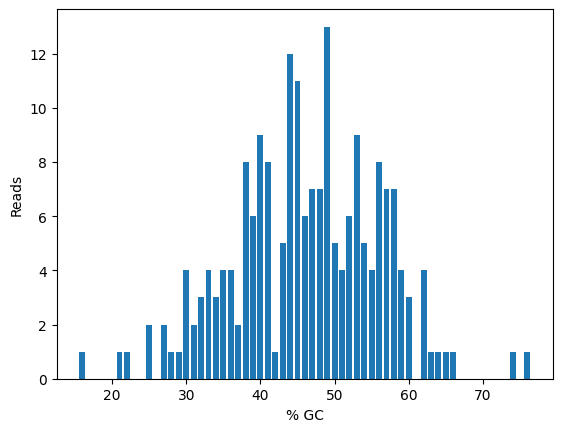

In [4]:
print("Generowanie histogramu...")
plot_gc_content(df_with_gc)

## 4. Porównanie z fastqc

In [5]:
# Pozyskiwanie raportu z fastqc
fastqc_report = !fqc -q ../../tests/data/example.fastq
fastqc_report = "\n".join(fastqc_report)
# Parsowanie raportu w celu pozysakanai gc count
pattern = r'{"count":\d+,"gc_pct":\d+,"type":"gc"}'
matches = re.findall(pattern, fastqc_report)
gc_data = [json.loads(m) for m in matches]
# Tworzenie porównania tabel
df_gc = pd.DataFrame(gc_data).rename(columns={"gc_pct": "gc"})
df_gc = df_gc.drop(columns=["type"]).sort_values("gc").reset_index(drop=True)
df_polars = df_with_gc.to_pandas().rename(columns={"count": "count_polars"})
df_fastqc = df_gc.rename(columns={"count": "count_fastqc"})
df_compare = pd.merge(
    df_polars[["gc", "count_polars"]],
    df_fastqc[["gc", "count_fastqc"]],
    on="gc",
    how="outer"
)
df_compare["diff"] = df_compare["count_polars"].fillna(0) - df_compare["count_fastqc"].fillna(0)
display(df_compare)
if (df_compare["diff"] != 0).any():
    print("Znaleziono różnice w obliczeniach GC:\n")
    display(df_compare[df_compare["diff"] != 0])
else:
    print("Brak różnic - wszystkie wartości count się zgadzają.")

,gc,count_polars,count_fastqc,diff
0,16,1,1,0
1,21,1,1,0
2,22,1,1,0
3,25,2,2,0
4,27,2,2,0
5,28,1,1,0
6,29,1,1,0
7,30,4,4,0
8,31,2,2,0
9,32,3,3,0


Brak różnic - wszystkie wartości count się zgadzają.
